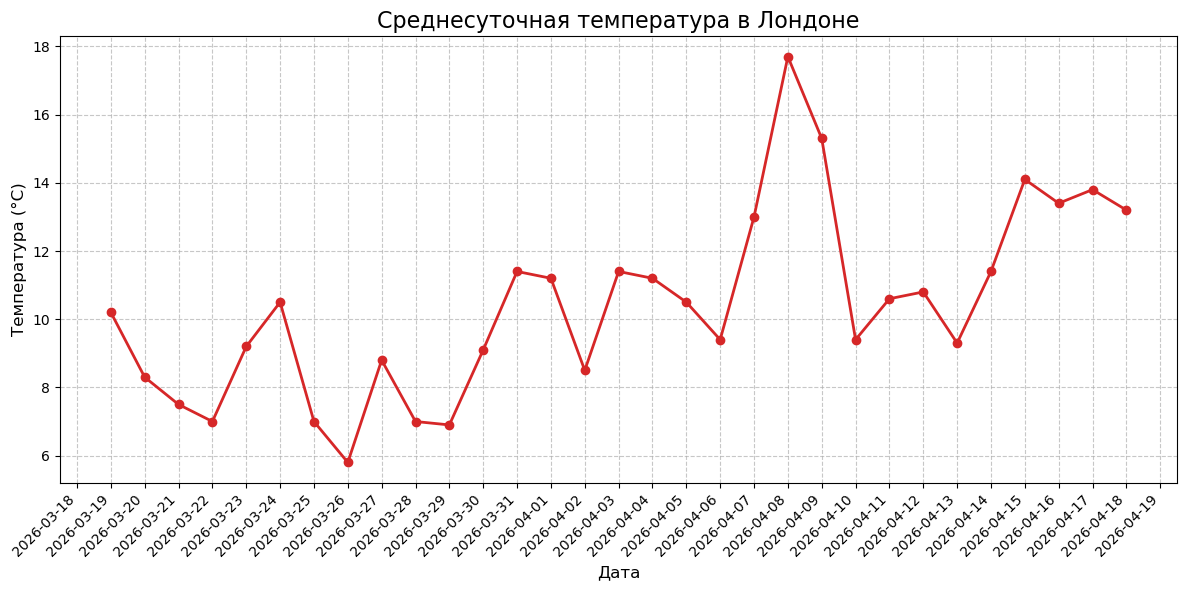

In [14]:
import ipynbname
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from IPython.display import Markdown

base_dir = ipynbname.path().parent.parent
filename = "mart_daily_visualization"
fn = filename+".csv"
mart_data = pd.read_csv(base_dir / "data" / "mart" / fn)
mart_data["date"] = pd.to_datetime(mart_data["date"])
mart_data = mart_data.sort_values("date")

plt.figure(figsize=(12, 6))
plt.plot(mart_data['date'], mart_data['avg_temperature_2m'], marker='o', linestyle='-', color='tab:red', linewidth=2, markersize=6)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gcf().autofmt_xdate(rotation=45)

plt.title('Среднесуточная температура в Лондоне', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

timeseries_path = base_dir / "docs" / "figures" / f'timeseries_{filename}.png'
timeseries_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(timeseries_path, dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

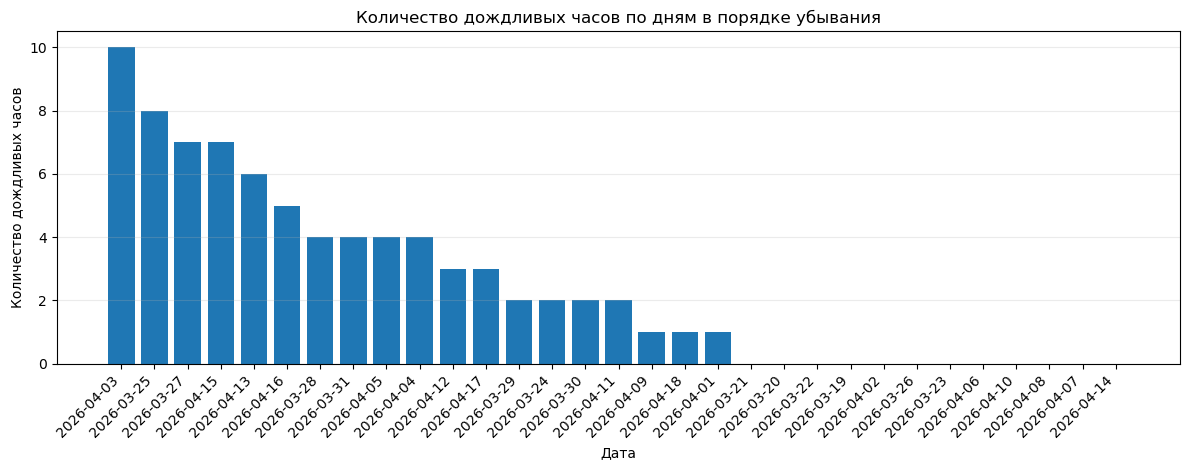

In [15]:
mart_sorted = mart_data.sort_values("rainy_hours", ascending=False)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(range(len(mart_sorted)), mart_sorted["rainy_hours"])

ax.set_xticks(range(len(mart_sorted)))
ax.set_xticklabels(mart_sorted["date"].dt.strftime('%Y-%m-%d'), rotation=45, ha='right')

ax.set_title("Количество дождливых часов по дням в порядке убывания")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество дождливых часов")
ax.grid(True, axis="y", alpha=0.25)

plt.savefig(base_dir / "docs" / "figures" / f'ranking_{filename}.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

Корреляция: 0.607


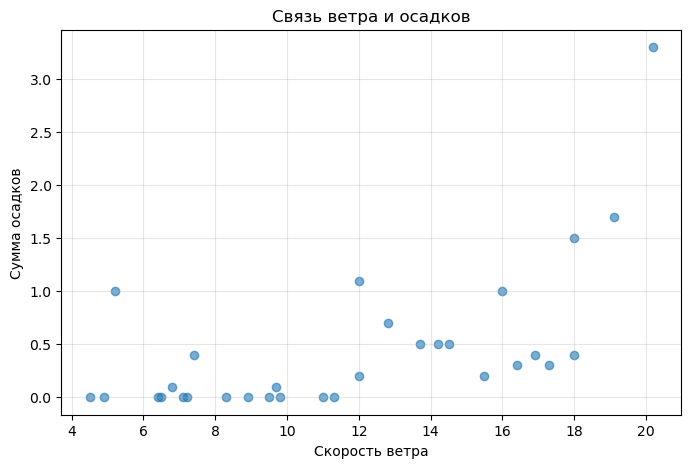

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(mart_data['avg_wind_speed_10m'], mart_data['sum_precipitation'], alpha=0.6)
plt.xlabel('Скорость ветра')
plt.ylabel('Сумма осадков')
plt.title('Связь ветра и осадков')
plt.grid(True, alpha=0.3)

correlation = mart_data['avg_wind_speed_10m'].corr(mart_data['sum_precipitation'])
print(f"Корреляция: {correlation:.3f}")

plt.savefig(base_dir / "docs" / "figures" / f'distribution_{filename}.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
conclusion_text = f"""
### Вывод

1. **Динамика среднесуточной температуры.**
Самая высокая температура была 18 апреля - почти 18 °C, самая низкая - 26 марта, 6 °C. График демонстрирует резкие перепады температуры на протяжении рассматриваемого периода. Несмотря на общее потепление, наблюдаются дни с резким похолоданием (2026-03-25, 2026-04-10), сменяющиеся резким ростом температуры в течение 2-3 дней.

2. **Количество дождливых часов.**
Всего за рассматриваемый период наблюдалось 19 дней с осадками. Максимальное количество часов, когда шел дождь, пришлось на 3 апреля - 10, тогда как в основном осадки выпадали в течение 2 - 6 часов. Это говорит о том, что данный период был умеренно дождливым с продолжительными осадками.

3. **Связь скорости ветра и суммы осадков.**
Коэффициент корреляции составляет {correlation}, что указывает на умеренную связь между ветром и осадками. На диаграмме рассеяния видно, что при слабом ветре осадки, как правило, незначительны. Наибольшие суммы осадков наблюдаются при скорости ветра от 12 м/с.
"""
display(Markdown(conclusion_text))


### Вывод

1. **Динамика среднесуточной температуры.**
Самая высокая температура была 18 апреля - почти 18 °C, самая низкая - 26 марта, 6 °C. График демонстрирует резкие перепады температуры на протяжении рассматриваемого периода. Несмотря на общее потепление, наблюдаются дни с резким похолоданием (2026-03-25, 2026-04-10), сменяющиеся резким ростом температуры в течение 2-3 дней.

2. **Количество дождливых часов.**
Всего за рассматриваемый период наблюдалось 19 дней с осадками. Максимальное количество часов, когда шел дождь, пришлось на 3 апреля - 10, тогда как в основном осадки выпадали в течение 2 - 6 часов. Это говорит о том, что данный период был умеренно дождливым с продолжительными осадками.

3. **Связь скорости ветра и суммы осадков.**
Коэффициент корреляции составляет 0.6070823296354857, что указывает на умеренную связь между ветром и осадками. На диаграмме рассеяния видно, что при слабом ветре осадки, как правило, незначительны. Наибольшие суммы осадков наблюдаются при скорости ветра от 12 м/с.
